In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import random
import copy

import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

from util import view_10, num_params
from data import fetch_dataset, data_to_tensor, iid_partition_loader, noniid_partition_loader

In [ ]:

# set random seeds -> 실험의 재현성 확보
np.random.seed(0)
torch.manual_seed(0)
random.seed(0)

# set device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("| using device:", device)

| using device: cpu


In [ ]:

# hyperparams
bsz = 10

100%|██████████| 9.91M/9.91M [00:00<00:00, 34.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.06MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.2MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.14MB/s]


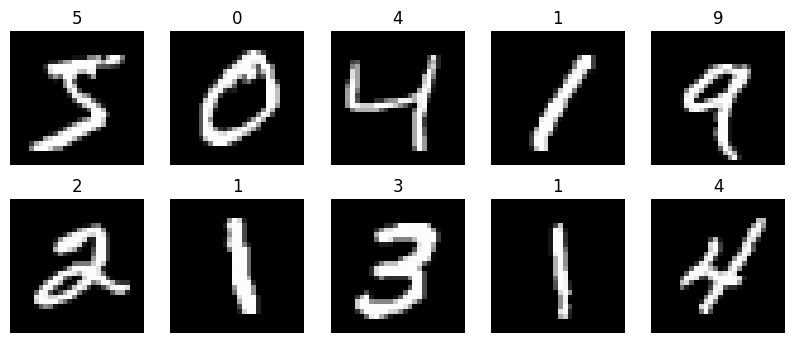

In [ ]:

# data load
train_data, test_data = fetch_dataset()

# 테스트용 데이터 공급기
test_loader = torch.utils.data.DataLoader(test_data, batch_size = 1000, shuffle=False) # inference bsz=1000

# 디버깅용 임시 데이터 공급기
debug_loader = torch.utils.data.DataLoader(train_data, bsz)

img, label = next(iter(debug_loader))
view_10(img, label)

In [ ]:

# get client dataloaders
iid_client_train_loader = iid_partition_loader(train_data, bsz = bsz)
noniid_client_train_loader = noniid_partition_loader(train_data, bsz = bsz)

iid:  tensor([59., 67., 65., 61., 55., 52., 55., 64., 48., 74.])


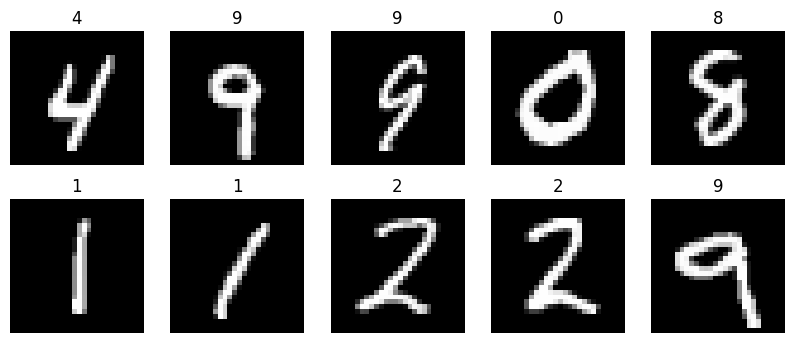

In [ ]:

# iid
label_dist = torch.zeros(10)
for (x,y) in iid_client_train_loader[25]:
    label_dist+= torch.sum(F.one_hot(y, num_classes=10), dim=0)
print("iid: ", label_dist)
view_10(x,y)

non-iid:  tensor([300.,   0.,   0., 300.,   0.,   0.,   0.,   0.,   0.,   0.])


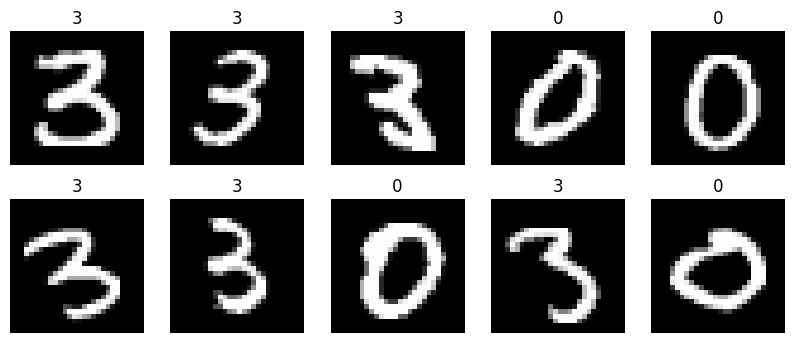

In [ ]:

# non-iid
label_dist = torch.zeros(10)
for (x,y) in noniid_client_train_loader[25]:
    label_dist+= torch.sum(F.one_hot(y,num_classes=10), dim=0)
print("non-iid: ", label_dist)
view_10(x,y)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=5, padding=2)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(64 * 7 * 7, 512)
        self.fc2 = nn.Linear(512, 10)


    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.flatten(1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

print(CNN())
print(num_params(CNN()))

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (conv2): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=10, bias=True)
)
1663370


In [ ]:
# 손실 함수 설정 -> 검증 정확도 계산
criterion = nn.CrossEntropyLoss()

def validate(model):
    model = model.to(device)
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for (t, (x,y)) in enumerate(test_loader):
            x = x.to(device)
            y = y.to(device)
            out = model(x)
            # 각 샘플별 가장 높은 점수를 클래스 예측으로 선택 후 실제 라벨(y)와 비교
            correct += torch.sum(torch.argmax(out, dim=1) == y).item()
            total += x.shape[0]
    return correct/total

In [ ]:
# local 학습
def train_client(id, client_loader, global_model, num_local_epochs, lr):
    local_model = copy.deepcopy(global_model) # global model을 복사하여 독립적인 local model 생성
    local_model = local_model.to(device)
    local_model.train()
    optimizer = torch.optim.SGD(local_model.parameters(), lr=lr)

    for epoch in range(num_local_epochs):
        for (i, (x,y)) in enumerate(client_loader):
            x = x.to(device)
            y = y.to(device)
            optimizer.zero_grad()
            out = local_model(x)  # 예측 결과 도출
            loss = criterion(out, y)
            loss.backward() # 역전파
            optimizer.step()  # 파라미터 갱신
    return local_model

# 가중평균
def running_model_avg(current, next, scale):
    if current == None: # current : 모델 가중치들의 누적합
        current = next
        for key in current:
            current[key] = current[key] * scale
    else:
        for key in current:
            current[key] = current[key] + (next[key] * scale) # 가중 누적합
    return current

In [ ]:
def fed_avg_experiment(global_model, num_clients_per_round, num_local_epochs, lr, client_train_loader, max_rounds, filename):
    round_accuracy = []
    current_lr = lr  # 초기 학습률 저장

    for t in range(max_rounds):
        print(f"starting round {t}, learning rate: {current_lr:.5f}")

        # 매 10 라운드마다 학습률 0.95배 감소
        if t > 0 and t % 10 == 0:
            current_lr *= 0.95
            print(f"Learning rate decayed to {current_lr:.5f} at round {t}")

        # choose clients randomly
        clients = np.random.choice(np.arange(100), num_clients_per_round, replace=False)
        print("clients: ", clients)

        global_model.eval()
        global_model = global_model.to('cpu')
        running_avg = None

        for i, c in enumerate(clients):
            # train local client
            print(f"round {t}, starting client {i+1}/{num_clients_per_round}, id: {c}")
            local_model = train_client(c, client_train_loader[c], global_model, num_local_epochs, current_lr)

            # add local model parameters to running average
            running_avg = running_model_avg(running_avg, local_model.state_dict(), 1 / num_clients_per_round)

        # global model parameter update
        global_model.load_state_dict(running_avg)

        # validate using test set
        val_acc = validate(global_model)
        print(f"round {t}, validation acc: {val_acc}")
        round_accuracy.append(val_acc)

        if t % 10 == 0:
            np.save(filename + f'_{t}.npy', np.array(round_accuracy))

    return np.array(round_accuracy)


In [ ]:

cnn = CNN()
print(cnn)
print("total params: ", num_params(cnn))

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (conv2): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=10, bias=True)
)
total params:  1663370


In [ ]:
def check_client_class_distribution(client_loaders):
    """
    각 클라이언트가 가진 고유 클래스 목록과 개수를 출력하고,
    클래스 수(1, 2, 3개)별 클라이언트 수를 집계
    """
    count_by_class_num = {1: 0, 2: 0, 3: 0}

    for client_id, loader in enumerate(client_loaders):
        all_labels = []
        for _, labels in loader:
            all_labels.extend(labels.tolist())
        unique_classes = sorted(set(all_labels))
        n_classes = len(unique_classes)

        # 클라이언트별 클래스 정보 출력
        print(f"Client {client_id:3d}: {n_classes} classes -> {unique_classes}")

        # 1, 2, 3개 클래스 수만 카운트
        if n_classes in count_by_class_num:
            count_by_class_num[n_classes] += 1

    # 요약 결과 출력
    print("\n=== 클래스 수별 클라이언트 수 통계 ===")
    for k in sorted(count_by_class_num.keys()):
        print(f"{k}개 클래스: {count_by_class_num[k]}명")

# 사용 예시
print("=== Non-IID 데이터 클래스 분포 확인 ===")
check_client_class_distribution(noniid_client_train_loader)


=== Non-IID 데이터 클래스 분포 확인 ===
Client   0: 2 classes -> [6, 9]
Client   1: 2 classes -> [1, 8]
Client   2: 2 classes -> [4, 7]
Client   3: 2 classes -> [4, 9]
Client   4: 2 classes -> [2, 4]
Client   5: 2 classes -> [0, 3]
Client   6: 2 classes -> [3, 5]
Client   7: 2 classes -> [7, 8]
Client   8: 2 classes -> [8, 9]
Client   9: 2 classes -> [1, 2]
Client  10: 2 classes -> [0, 7]
Client  11: 2 classes -> [4, 6]
Client  12: 2 classes -> [5, 9]
Client  13: 1 classes -> [1]
Client  14: 1 classes -> [5]
Client  15: 2 classes -> [0, 1]
Client  16: 2 classes -> [0, 8]
Client  17: 2 classes -> [4, 6]
Client  18: 2 classes -> [5, 7]
Client  19: 3 classes -> [2, 4, 5]
Client  20: 2 classes -> [2, 9]
Client  21: 2 classes -> [0, 5]
Client  22: 2 classes -> [4, 8]
Client  23: 2 classes -> [4, 8]
Client  24: 3 classes -> [7, 8, 9]
Client  25: 2 classes -> [0, 3]
Client  26: 2 classes -> [2, 5]
Client  27: 2 classes -> [1, 9]
Client  28: 2 classes -> [6, 8]
Client  29: 2 classes -> [6, 8]
Client  30

In [ ]:

# CNN - iid - B=10 E=5
cnn_iid_m10 = copy.deepcopy(cnn)
acc_cnn_iid_b10e5 = fed_avg_experiment(cnn_iid_m10, num_clients_per_round=10,
                                 num_local_epochs=5,
                                 lr=0.05,
                                 client_train_loader = iid_client_train_loader,
                                 max_rounds=200,
                                 filename='./acc_cnn_iid_b10e5')
print(acc_cnn_iid_b10e5)
drive_save_path = '/content/drive/MyDrive/FedAvg/acc_cnn_iid_b10e5.npy'
np.save(drive_save_path, acc_cnn_iid_b10e5)
print(f"Saved to {drive_save_path}")

starting round 0, learning rate: 0.05000
clients:  [26 86  2 55 75 93 16 73 54 95]
round 0, starting client 1/10, id: 26
round 0, starting client 2/10, id: 86
round 0, starting client 3/10, id: 2
round 0, starting client 4/10, id: 55
round 0, starting client 5/10, id: 75
round 0, starting client 6/10, id: 93
round 0, starting client 7/10, id: 16
round 0, starting client 8/10, id: 73
round 0, starting client 9/10, id: 54
round 0, starting client 10/10, id: 95
round 0, validation acc: 0.951
starting round 1, learning rate: 0.05000
clients:  [18 29 64 92 72 87  5 15 12 17]
round 1, starting client 1/10, id: 18
round 1, starting client 2/10, id: 29
round 1, starting client 3/10, id: 64
round 1, starting client 4/10, id: 92
round 1, starting client 5/10, id: 72
round 1, starting client 6/10, id: 87
round 1, starting client 7/10, id: 5
round 1, starting client 8/10, id: 15
round 1, starting client 9/10, id: 12
round 1, starting client 10/10, id: 17
round 1, validation acc: 0.9674
starting ro

In [ ]:

# CNN - iid - B=10 E=1
cnn_iid_m10 = copy.deepcopy(cnn)
acc_cnn_iid_b10e1 = fed_avg_experiment(cnn_iid_m10, num_clients_per_round=10,
                                 num_local_epochs=1,
                                 lr=0.05,
                                 client_train_loader = iid_client_train_loader,
                                 max_rounds=200,
                                 filename='./acc_cnn_iid_b10e1')
print(acc_cnn_iid_b10e1)
drive_save_path = '/content/drive/MyDrive/FedAvg/acc_cnn_iid_b10e1.npy'
np.save(drive_save_path, acc_cnn_iid_b10e1)
print(f"Saved to {drive_save_path}")

starting round 0, learning rate: 0.05000
clients:  [26 86  2 55 75 93 16 73 54 95]
round 0, starting client 1/10, id: 26
round 0, starting client 2/10, id: 86
round 0, starting client 3/10, id: 2
round 0, starting client 4/10, id: 55
round 0, starting client 5/10, id: 75
round 0, starting client 6/10, id: 93
round 0, starting client 7/10, id: 16
round 0, starting client 8/10, id: 73
round 0, starting client 9/10, id: 54
round 0, starting client 10/10, id: 95
round 0, validation acc: 0.8716
starting round 1, learning rate: 0.05000
clients:  [18 29 64 92 72 87  5 15 12 17]
round 1, starting client 1/10, id: 18
round 1, starting client 2/10, id: 29
round 1, starting client 3/10, id: 64
round 1, starting client 4/10, id: 92
round 1, starting client 5/10, id: 72
round 1, starting client 6/10, id: 87
round 1, starting client 7/10, id: 5
round 1, starting client 8/10, id: 15
round 1, starting client 9/10, id: 12
round 1, starting client 10/10, id: 17
round 1, validation acc: 0.9208
starting r

In [ ]:

# CNN - non-iid - B=10 E=5
cnn_noniid_m10 = copy.deepcopy(cnn)
acc_cnn_noniid_b10e5_300 = fed_avg_experiment(cnn_noniid_m10, num_clients_per_round=10,
                                 num_local_epochs=5,
                                 lr=0.05,
                                 client_train_loader = noniid_client_train_loader,
                                 max_rounds=300,
                                 filename='./acc_cnn_noniid_b10e5_300')
print(acc_cnn_noniid_b10e5_300)
drive_save_path = '/content/drive/MyDrive/FedAvg/acc_cnn_noniid_b10e5_300.npy'
np.save(drive_save_path, acc_cnn_noniid_b10e5_300)
print(f"Saved to {drive_save_path}")

starting round 0, learning rate: 0.05000
clients:  [26 86  2 55 75 93 16 73 54 95]
round 0, starting client 1/10, id: 26
round 0, starting client 2/10, id: 86
round 0, starting client 3/10, id: 2
round 0, starting client 4/10, id: 55
round 0, starting client 5/10, id: 75
round 0, starting client 6/10, id: 93
round 0, starting client 7/10, id: 16
round 0, starting client 8/10, id: 73
round 0, starting client 9/10, id: 54
round 0, starting client 10/10, id: 95
round 0, validation acc: 0.384
starting round 1, learning rate: 0.05000
clients:  [18 29 64 92 72 87  5 15 12 17]
round 1, starting client 1/10, id: 18
round 1, starting client 2/10, id: 29
round 1, starting client 3/10, id: 64
round 1, starting client 4/10, id: 92
round 1, starting client 5/10, id: 72
round 1, starting client 6/10, id: 87
round 1, starting client 7/10, id: 5
round 1, starting client 8/10, id: 15
round 1, starting client 9/10, id: 12
round 1, starting client 10/10, id: 17
round 1, validation acc: 0.5544
starting ro

In [ ]:

# CNN - non-iid - B=10 E=1
cnn_noniid_m10 = copy.deepcopy(cnn)
acc_cnn_noniid_b10e1_300 = fed_avg_experiment(cnn_noniid_m10, num_clients_per_round=10,
                                 num_local_epochs=1,
                                 lr=0.05,
                                 client_train_loader = noniid_client_train_loader,
                                 max_rounds=300,
                                 filename='./acc_cnn_noniid_b10e1_300')
print(acc_cnn_noniid_b10e1_300)
drive_save_path = '/content/drive/MyDrive/FedAvg/acc_cnn_noniid_b10e1_300.npy'
np.save(drive_save_path, acc_cnn_noniid_b10e1_300)
print(f"Saved to {drive_save_path}")

starting round 0, learning rate: 0.05000
clients:  [31 58 14 25 65 15 46 82 70 48]
round 0, starting client 1/10, id: 31
round 0, starting client 2/10, id: 58
round 0, starting client 3/10, id: 14
round 0, starting client 4/10, id: 25
round 0, starting client 5/10, id: 65
round 0, starting client 6/10, id: 15
round 0, starting client 7/10, id: 46
round 0, starting client 8/10, id: 82
round 0, starting client 9/10, id: 70
round 0, starting client 10/10, id: 48
round 0, validation acc: 0.09
starting round 1, learning rate: 0.05000
clients:  [68 35 84 53 79 70 61 85 25 73]
round 1, starting client 1/10, id: 68
round 1, starting client 2/10, id: 35
round 1, starting client 3/10, id: 84
round 1, starting client 4/10, id: 53
round 1, starting client 5/10, id: 79
round 1, starting client 6/10, id: 70
round 1, starting client 7/10, id: 61
round 1, starting client 8/10, id: 85
round 1, starting client 9/10, id: 25
round 1, starting client 10/10, id: 73
round 1, validation acc: 0.4619
starting r

In [ ]:
bsz=50

In [ ]:

# get client dataloaders
iid_client_train_loader = iid_partition_loader(train_data, bsz = bsz)
noniid_client_train_loader = noniid_partition_loader(train_data, bsz = bsz)

In [ ]:
# CNN - non-iid - B=50 E=5
cnn_noniid_m10 = copy.deepcopy(cnn)
acc_cnn_noniid_b50e5_300 = fed_avg_experiment(cnn_noniid_m10, num_clients_per_round=10,
                                 num_local_epochs=5,
                                 lr=0.05,
                                 client_train_loader = noniid_client_train_loader,
                                 max_rounds=300,
                                 filename='./acc_cnn_noniid_b50e5_300')
print(acc_cnn_noniid_b50e5_300)
drive_save_path = '/content/drive/MyDrive/FedAvg/acc_cnn_noniid_b50e5_300.npy'
np.save(drive_save_path, acc_cnn_noniid_b50e5_300)
print(f"Saved to {drive_save_path}")

starting round 0, learning rate: 0.05000
clients:  [42 96 58 14 72  4 47 64 57 63]
round 0, starting client 1/10, id: 42
round 0, starting client 2/10, id: 96
round 0, starting client 3/10, id: 58
round 0, starting client 4/10, id: 14
round 0, starting client 5/10, id: 72
round 0, starting client 6/10, id: 4
round 0, starting client 7/10, id: 47
round 0, starting client 8/10, id: 64
round 0, starting client 9/10, id: 57
round 0, starting client 10/10, id: 63
round 0, validation acc: 0.354
starting round 1, learning rate: 0.05000
clients:  [54 84 33 53  2 49 48 82 41 66]
round 1, starting client 1/10, id: 54
round 1, starting client 2/10, id: 84
round 1, starting client 3/10, id: 33
round 1, starting client 4/10, id: 53
round 1, starting client 5/10, id: 2
round 1, starting client 6/10, id: 49
round 1, starting client 7/10, id: 48
round 1, starting client 8/10, id: 82
round 1, starting client 9/10, id: 41
round 1, starting client 10/10, id: 66
round 1, validation acc: 0.3828
starting ro

In [ ]:

# CNN - non-iid - B=50 E=1
cnn_noniid_m10 = copy.deepcopy(cnn)
acc_cnn_noniid_b50e1_300 = fed_avg_experiment(cnn_noniid_m10, num_clients_per_round=10,
                                 num_local_epochs=1,
                                 lr=0.05,
                                 client_train_loader = noniid_client_train_loader,
                                 max_rounds=300,
                                 filename='./acc_cnn_noniid_b50e1_300')
print(acc_cnn_noniid_b50e1_300)
drive_save_path = '/content/drive/MyDrive/FedAvg/acc_cnn_noniid_b50e1_300.npy'
np.save(drive_save_path, acc_cnn_noniid_b50e1_300)
print(f"Saved to {drive_save_path}")

starting round 0, learning rate: 0.05000
clients:  [57 34 16 78 69 95 83 50 68 21]
round 0, starting client 1/10, id: 57
round 0, starting client 2/10, id: 34
round 0, starting client 3/10, id: 16
round 0, starting client 4/10, id: 78
round 0, starting client 5/10, id: 69
round 0, starting client 6/10, id: 95
round 0, starting client 7/10, id: 83
round 0, starting client 8/10, id: 50
round 0, starting client 9/10, id: 68
round 0, starting client 10/10, id: 21
round 0, validation acc: 0.3
starting round 1, learning rate: 0.05000
clients:  [50 65 15 41 94 77 43 61 53 55]
round 1, starting client 1/10, id: 50
round 1, starting client 2/10, id: 65
round 1, starting client 3/10, id: 15
round 1, starting client 4/10, id: 41
round 1, starting client 5/10, id: 94
round 1, starting client 6/10, id: 77
round 1, starting client 7/10, id: 43
round 1, starting client 8/10, id: 61
round 1, starting client 9/10, id: 53
round 1, starting client 10/10, id: 55
round 1, validation acc: 0.2816
starting ro

In [ ]:
bsz = 600

In [ ]:

# get client dataloaders
iid_client_train_loader = iid_partition_loader(train_data, bsz = bsz)
noniid_client_train_loader = noniid_partition_loader(train_data, bsz = bsz)

In [ ]:

# CNN - non-iid - B=∞ E=1
cnn_noniid_m10 = copy.deepcopy(cnn)
acc_cnn_noniid_b600e1_300_1 = fed_avg_experiment(cnn_noniid_m10, num_clients_per_round=10,
                                 num_local_epochs=1,
                                 lr=0.05,
                                 client_train_loader = noniid_client_train_loader,
                                 max_rounds=300,
                                 filename='./acc_cnn_noniid_b600e1_300_1')
print(acc_cnn_noniid_b600e1_300_1)
drive_save_path = '/content/drive/MyDrive/FedAvg/acc_cnn_noniid_b600e1_300_1.npy'
np.save(drive_save_path, acc_cnn_noniid_b600e1_300_1)
print(f"Saved to {drive_save_path}")

starting round 0, learning rate: 0.05000
clients:  [26 86  2 55 75 93 16 73 54 95]
round 0, starting client 1/10, id: 26
round 0, starting client 2/10, id: 86
round 0, starting client 3/10, id: 2
round 0, starting client 4/10, id: 55
round 0, starting client 5/10, id: 75
round 0, starting client 6/10, id: 93
round 0, starting client 7/10, id: 16
round 0, starting client 8/10, id: 73
round 0, starting client 9/10, id: 54
round 0, starting client 10/10, id: 95
round 0, validation acc: 0.1206
starting round 1, learning rate: 0.05000
clients:  [18 29 64 92 72 87  5 15 12 17]
round 1, starting client 1/10, id: 18
round 1, starting client 2/10, id: 29
round 1, starting client 3/10, id: 64
round 1, starting client 4/10, id: 92
round 1, starting client 5/10, id: 72
round 1, starting client 6/10, id: 87
round 1, starting client 7/10, id: 5
round 1, starting client 8/10, id: 15
round 1, starting client 9/10, id: 12
round 1, starting client 10/10, id: 17
round 1, validation acc: 0.1066
starting r

In [ ]:

# CNN - non-iid - B=∞ E=5
cnn_noniid_m10 = copy.deepcopy(cnn)
acc_cnn_noniid_b600e5_300_1 = fed_avg_experiment(cnn_noniid_m10, num_clients_per_round=10,
                                 num_local_epochs=5,
                                 lr=0.05,
                                 client_train_loader = noniid_client_train_loader,
                                 max_rounds=300,
                                 filename='./acc_cnn_noniid_b600e5_300_1')
print(acc_cnn_noniid_b600e5_300_1)
drive_save_path = '/content/drive/MyDrive/FedAvg/acc_cnn_noniid_b600e5_300_1.npy'
np.save(drive_save_path, acc_cnn_noniid_b600e5_300_1)
print(f"Saved to {drive_save_path}")

starting round 0, learning rate: 0.05000
clients:  [26 86  2 55 75 93 16 73 54 95]
round 0, starting client 1/10, id: 26
round 0, starting client 2/10, id: 86
round 0, starting client 3/10, id: 2
round 0, starting client 4/10, id: 55
round 0, starting client 5/10, id: 75
round 0, starting client 6/10, id: 93
round 0, starting client 7/10, id: 16
round 0, starting client 8/10, id: 73
round 0, starting client 9/10, id: 54
round 0, starting client 10/10, id: 95
round 0, validation acc: 0.1032
starting round 1, learning rate: 0.05000
clients:  [18 29 64 92 72 87  5 15 12 17]
round 1, starting client 1/10, id: 18
round 1, starting client 2/10, id: 29
round 1, starting client 3/10, id: 64
round 1, starting client 4/10, id: 92
round 1, starting client 5/10, id: 72
round 1, starting client 6/10, id: 87
round 1, starting client 7/10, id: 5
round 1, starting client 8/10, id: 15
round 1, starting client 9/10, id: 12
round 1, starting client 10/10, id: 17
round 1, validation acc: 0.1478
starting r

In [ ]:

# CNN - iid - B=∞ E=1
cnn_iid_m50 = copy.deepcopy(cnn)
acc_cnn_iid_b600e1 = fed_avg_experiment(cnn_iid_m50, num_clients_per_round=10,
                                 num_local_epochs=1,
                                 lr=0.1,
                                 client_train_loader = iid_client_train_loader,
                                 max_rounds=200,
                                 filename='./acc_cnn_iid_b600e1')
print(acc_cnn_iid_b600e1)
drive_save_path = '/content/drive/MyDrive/FedAvg/acc_cnn_iid_b600e1.npy'
np.save(drive_save_path, acc_cnn_iid_b600e1)
print(f"Saved to {drive_save_path}")

starting round 0, learning rate: 0.10000
clients:  [17 87  9  4 47 62 16 52 33 44]
round 0, starting client 1/10, id: 17
round 0, starting client 2/10, id: 87
round 0, starting client 3/10, id: 9
round 0, starting client 4/10, id: 4
round 0, starting client 5/10, id: 47
round 0, starting client 6/10, id: 62
round 0, starting client 7/10, id: 16
round 0, starting client 8/10, id: 52
round 0, starting client 9/10, id: 33
round 0, starting client 10/10, id: 44
round 0, validation acc: 0.2088
starting round 1, learning rate: 0.10000
clients:  [72 22 86 98 83 51 74 75 50 94]
round 1, starting client 1/10, id: 72
round 1, starting client 2/10, id: 22
round 1, starting client 3/10, id: 86
round 1, starting client 4/10, id: 98
round 1, starting client 5/10, id: 83
round 1, starting client 6/10, id: 51
round 1, starting client 7/10, id: 74
round 1, starting client 8/10, id: 75
round 1, starting client 9/10, id: 50
round 1, starting client 10/10, id: 94
round 1, validation acc: 0.3853
starting r

In [ ]:

# CNN - iid - B=∞ E=1
cnn_iid_m50 = copy.deepcopy(cnn)
acc_cnn_iid_b600e1_lr01 = fed_avg_experiment(cnn_iid_m50, num_clients_per_round=10,
                                 num_local_epochs=1,
                                 lr=0.15,
                                 client_train_loader = iid_client_train_loader,
                                 max_rounds=200,
                                 filename='./acc_cnn_iid_b600e1_lr01')
print(acc_cnn_iid_b600e1_lr01)
drive_save_path = '/content/drive/MyDrive/FedAvg/acc_cnn_iid_b600e1_lr01.npy'
np.save(drive_save_path, acc_cnn_iid_b600e1_lr01)
print(f"Saved to {drive_save_path}")

starting round 0, learning rate: 0.15000
clients:  [85 34  3  6 16 64 43 45 60 22]
round 0, starting client 1/10, id: 85
round 0, starting client 2/10, id: 34
round 0, starting client 3/10, id: 3
round 0, starting client 4/10, id: 6
round 0, starting client 5/10, id: 16
round 0, starting client 6/10, id: 64
round 0, starting client 7/10, id: 43
round 0, starting client 8/10, id: 45
round 0, starting client 9/10, id: 60
round 0, starting client 10/10, id: 22
round 0, validation acc: 0.2793
starting round 1, learning rate: 0.15000
clients:  [82 84 74 38 17 94 77 25 50 99]
round 1, starting client 1/10, id: 82
round 1, starting client 2/10, id: 84
round 1, starting client 3/10, id: 74
round 1, starting client 4/10, id: 38
round 1, starting client 5/10, id: 17
round 1, starting client 6/10, id: 94
round 1, starting client 7/10, id: 77
round 1, starting client 8/10, id: 25
round 1, starting client 9/10, id: 50
round 1, starting client 10/10, id: 99
round 1, validation acc: 0.5234
starting r

In [ ]:

# CNN - iid - B=∞ E=5
cnn_iid_m50 = copy.deepcopy(cnn)
acc_cnn_iid_b600e5 = fed_avg_experiment(cnn_iid_m50, num_clients_per_round=10,
                                 num_local_epochs=5,
                                 lr=0.1,
                                 client_train_loader = iid_client_train_loader,
                                 max_rounds=200,
                                 filename='./acc_cnn_iid_b600e5')
print(acc_cnn_iid_b600e5)
drive_save_path = '/content/drive/MyDrive/FedAvg/acc_cnn_iid_b600e5.npy'
np.save(drive_save_path, acc_cnn_iid_b600e5)
print(f"Saved to {drive_save_path}")

starting round 0, learning rate: 0.10000
clients:  [92 94  7 90  9 10 31 15 75  2]
round 0, starting client 1/10, id: 92
round 0, starting client 2/10, id: 94
round 0, starting client 3/10, id: 7
round 0, starting client 4/10, id: 90
round 0, starting client 5/10, id: 9
round 0, starting client 6/10, id: 10
round 0, starting client 7/10, id: 31
round 0, starting client 8/10, id: 15
round 0, starting client 9/10, id: 75
round 0, starting client 10/10, id: 2
round 0, validation acc: 0.651
starting round 1, learning rate: 0.10000
clients:  [84 78 53 31 75 65  0 59 12 87]
round 1, starting client 1/10, id: 84
round 1, starting client 2/10, id: 78
round 1, starting client 3/10, id: 53
round 1, starting client 4/10, id: 31
round 1, starting client 5/10, id: 75
round 1, starting client 6/10, id: 65
round 1, starting client 7/10, id: 0
round 1, starting client 8/10, id: 59
round 1, starting client 9/10, id: 12
round 1, starting client 10/10, id: 87
round 1, validation acc: 0.3285
starting roun

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:


acc_cnn_iid_b10e5 = np.load('/content/drive/MyDrive/FedAvg/acc_cnn_iid_b10e5.npy')
acc_cnn_iid_b10e1 = np.load('/content/drive/MyDrive/FedAvg/acc_cnn_iid_b10e1.npy')
acc_cnn_iid_b50e5 = np.load('/content/drive/MyDrive/FedAvg/acc_cnn_iid_b50e5.npy')
acc_cnn_iid_b50e1 = np.load('/content/drive/MyDrive/FedAvg/acc_cnn_iid_b50e1.npy')

acc_cnn_noniid_b10e5 = np.load('/content/drive/MyDrive/FedAvg/acc_cnn_noniid_b10e5.npy')
acc_cnn_noniid_b10e1 = np.load('/content/drive/MyDrive/FedAvg/acc_cnn_noniid_b10e1.npy')
acc_cnn_noniid_b50e5 = np.load('/content/drive/MyDrive/FedAvg/acc_cnn_noniid_b50e5.npy')
acc_cnn_noniid_b50e1 = np.load('/content/drive/MyDrive/FedAvg/acc_cnn_noniid_b50e1.npy')

acc_cnn_noniid_b10e5_300 = np.load('/content/drive/MyDrive/FedAvg/acc_cnn_noniid_b10e5_300.npy')
acc_cnn_noniid_b10e1_300 = np.load('/content/drive/MyDrive/FedAvg/acc_cnn_noniid_b10e1_300.npy')
acc_cnn_noniid_b50e5_300 = np.load('/content/drive/MyDrive/FedAvg/acc_cnn_noniid_b50e5_300.npy')
acc_cnn_noniid_b50e1_300 = np.load('/content/drive/MyDrive/FedAvg/acc_cnn_noniid_b50e1_300.npy')

acc_cnn_iid_b600e5 = np.load('/content/drive/MyDrive/FedAvg/acc_cnn_iid_b600e5.npy')
acc_cnn_iid_b600e1 = np.load('/content/drive/MyDrive/FedAvg/acc_cnn_iid_b600e1.npy')
acc_cnn_iid_b600e1_lr01 = np.load('/content/drive/MyDrive/FedAvg/acc_cnn_iid_b600e1_lr01.npy')
acc_cnn_noniid_b600e5_300 = np.load('/content/drive/MyDrive/FedAvg/acc_cnn_noniid_b600e5_300.npy')
acc_cnn_noniid_b600e1_300 = np.load('/content/drive/MyDrive/FedAvg/acc_cnn_noniid_b600e1_300.npy')

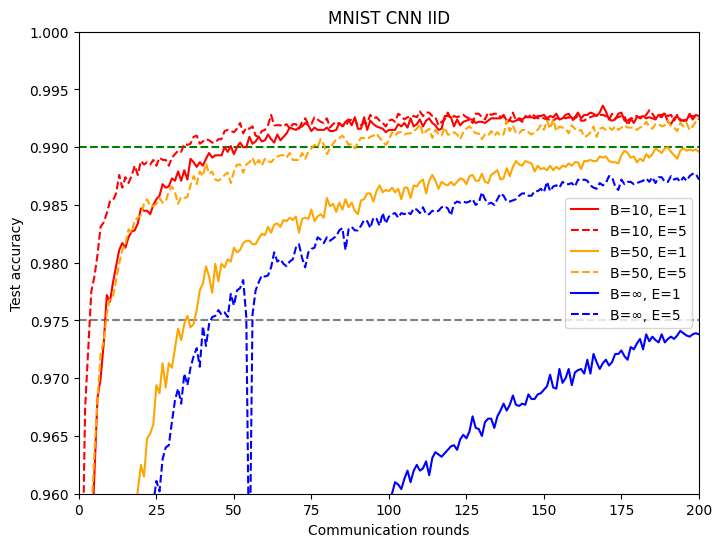

In [ ]:

x = np.arange(1, 201)
plt.figure(figsize=(8,6))

plt.title("MNIST CNN IID")
plt.xlabel("Communication rounds")
plt.ylabel("Test accuracy")
plt.axis([0, 200, 0.96, 1])

# 기준선

plt.axhline(y=0.99, color='g', linestyle='dashed')
plt.axhline(y=0.975, color='gray', linestyle='dashed')

# 실험 결과 선 그래프
plt.plot(x, acc_cnn_iid_b10e1, color='red', linestyle='-', label='B=10, E=1')
plt.plot(x, acc_cnn_iid_b10e5, color='red', linestyle='--', label='B=10, E=5')
plt.plot(x, acc_cnn_iid_b50e1, color='orange', linestyle='-', label='B=50, E=1')
plt.plot(x, acc_cnn_iid_b50e5, color='orange', linestyle='--', label='B=50, E=5')
plt.plot(x, acc_cnn_iid_b600e1_lr01, color='blue', linestyle='-', label='B=∞, E=1')
plt.plot(x, acc_cnn_iid_b600e5, color='blue', linestyle='--', label='B=∞, E=5')

plt.legend()
plt.show()


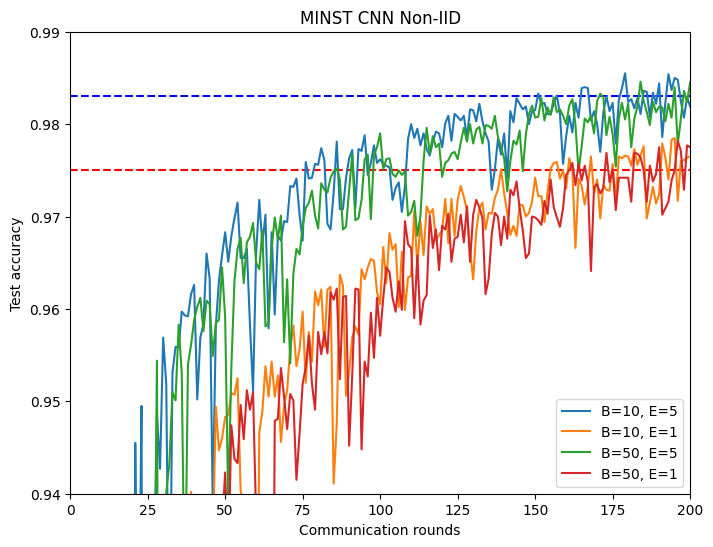

In [ ]:
x = np.arange(1,201)
plt.figure(figsize=(8,6))

plt.title("MINST CNN Non-IID")

plt.xlabel("Communication rounds")
plt.ylabel("Test accuracy")
plt.axis([0, 200, 0.94, 0.99])

plt.axhline(y=0.975, color='r', linestyle='dashed')
plt.axhline(y=0.983, color='b', linestyle='dashed')

plt.plot(x, acc_cnn_noniid_b10e5, label='B=10, E=5')
plt.plot(x, acc_cnn_noniid_b10e1, label='B=10, E=1')
plt.plot(x, acc_cnn_noniid_b50e5, label='B=50, E=5')
plt.plot(x, acc_cnn_noniid_b50e1, label='B=50, E=1')

plt.legend()

plt.show()

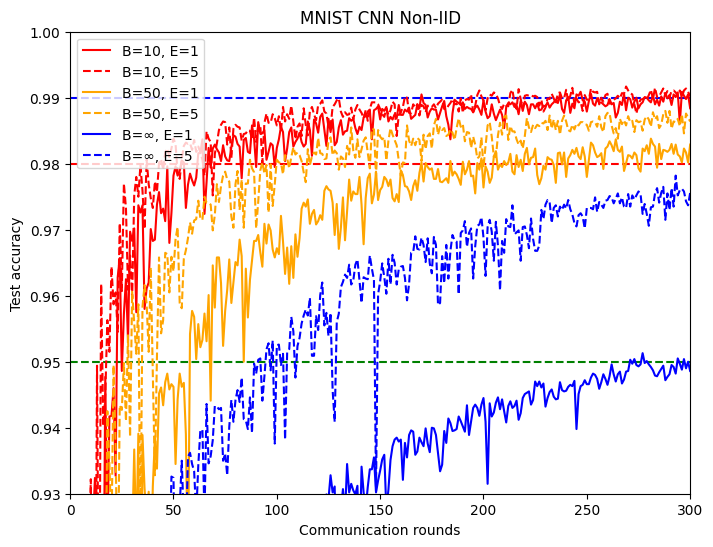

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(1, 301)
plt.figure(figsize=(8,6))

plt.title("MNIST CNN Non-IID")
plt.xlabel("Communication rounds")
plt.ylabel("Test accuracy")
plt.axis([0, 300, 0.93, 1])

# 기준선
plt.axhline(y=0.98, color='r', linestyle='dashed')
plt.axhline(y=0.99, color='b', linestyle='dashed')
plt.axhline(y=0.95, color='g', linestyle='dashed')

# 실험 결과 선 그래프
plt.plot(x, acc_cnn_noniid_b10e1_300, color='red', linestyle='-', label='B=10, E=1')
plt.plot(x, acc_cnn_noniid_b10e5_300, color='red', linestyle='--', label='B=10, E=5')
plt.plot(x, acc_cnn_noniid_b50e1_300, color='orange', linestyle='-', label='B=50, E=1')
plt.plot(x, acc_cnn_noniid_b50e5_300, color='orange', linestyle='--', label='B=50, E=5')
plt.plot(x, acc_cnn_noniid_b600e1_300, color='blue', linestyle='-', label='B=∞, E=1')
plt.plot(x, acc_cnn_noniid_b600e5_300, color='blue', linestyle='--', label='B=∞, E=5')

plt.legend()
plt.show()


In [ ]:
acc_cnn_noniid_b600e5_300_1 = np.load('/content/drive/MyDrive/FedAvg/acc_cnn_noniid_b600e5_300_1.npy')
acc_cnn_noniid_b600e1_300_1 = np.load('/content/drive/MyDrive/FedAvg/acc_cnn_noniid_b600e1_300_1.npy')

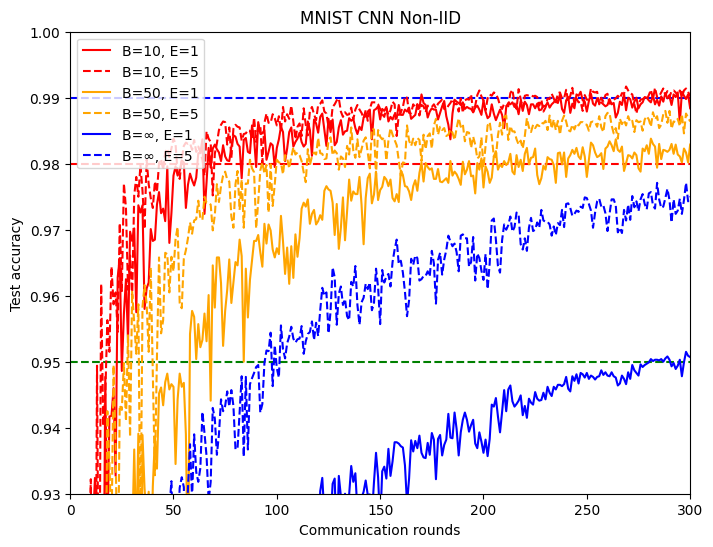

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(1, 301)
plt.figure(figsize=(8,6))

plt.title("MNIST CNN Non-IID")
plt.xlabel("Communication rounds")
plt.ylabel("Test accuracy")
plt.axis([0, 300, 0.93, 1])

# 기준선
plt.axhline(y=0.98, color='r', linestyle='dashed')
plt.axhline(y=0.99, color='b', linestyle='dashed')
plt.axhline(y=0.95, color='g', linestyle='dashed')

# 실험 결과 선 그래프
plt.plot(x, acc_cnn_noniid_b10e1_300, color='red', linestyle='-', label='B=10, E=1')
plt.plot(x, acc_cnn_noniid_b10e5_300, color='red', linestyle='--', label='B=10, E=5')
plt.plot(x, acc_cnn_noniid_b50e1_300, color='orange', linestyle='-', label='B=50, E=1')
plt.plot(x, acc_cnn_noniid_b50e5_300, color='orange', linestyle='--', label='B=50, E=5')
plt.plot(x, acc_cnn_noniid_b600e1_300_1, color='blue', linestyle='-', label='B=∞, E=1')
plt.plot(x, acc_cnn_noniid_b600e5_300_1, color='blue', linestyle='--', label='B=∞, E=5')

plt.legend()
plt.show()


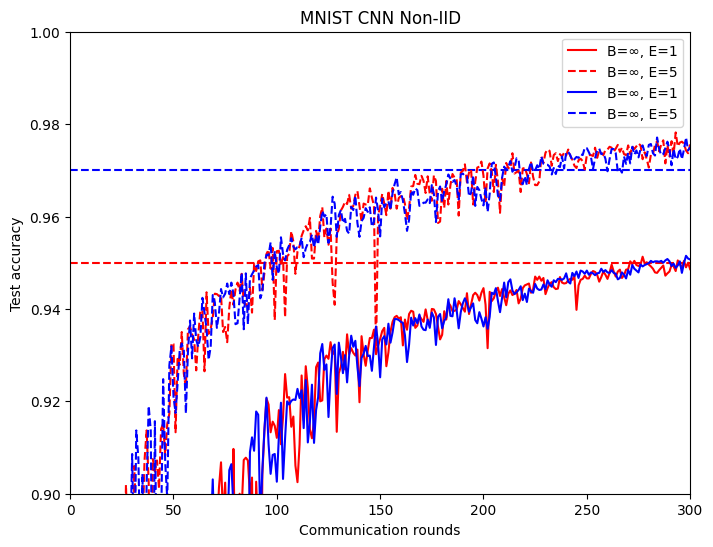

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(1, 301)
plt.figure(figsize=(8,6))

plt.title("MNIST CNN Non-IID")
plt.xlabel("Communication rounds")
plt.ylabel("Test accuracy")
plt.axis([0, 300, 0.9, 1])

# 기준선
plt.axhline(y=0.95, color='r', linestyle='dashed')
plt.axhline(y=0.97, color='b', linestyle='dashed')

# 실험 결과 선 그래프
plt.plot(x, acc_cnn_noniid_b600e1_300, color='red', linestyle='-', label='B=∞, E=1')
plt.plot(x, acc_cnn_noniid_b600e5_300, color='red', linestyle='--', label='B=∞, E=5')
plt.plot(x, acc_cnn_noniid_b600e1_300_1, color='blue', linestyle='-', label='B=∞, E=1')
plt.plot(x, acc_cnn_noniid_b600e5_300_1, color='blue', linestyle='--', label='B=∞, E=5')

plt.legend()
plt.show()
